Open a reduced/processed X-shooter spectrum from the pre-canned data archive pipeline (the science product you can download) and make a plot from it. This should be kind of straight-forward.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column

import spec_plot_tools as spt
import plot_spec as ps


all_avg


Now we have to put the X-shooter spectra somewhere and get them

In [2]:
target_dir='/Users/BenKaiser/Desktop/Xshooter/LHS_2534_Xshooter_data/'

In [3]:
#target_file='ADP.2019-02-12T14.14.28.768.fits' #JH spectra
#target_file='ADP.2019-02-12T14.14.29.026.fits' #JH spectra
#target_file='ADP.2019-02-12T14.14.28.739.fits' #VIS spectra
#target_file='ADP.2019-02-12T14.14.28.909.fits' #VIS spectra
target_file='ADP.2019-02-12T14.14.28.985.fits'
target_file=target_dir+target_file

In [4]:
hdu=fits.open(target_file)

In [5]:
print(hdu)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7fa763d0e860>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7fa763da14e0>]


In [6]:
header=fits.getheader(target_file)

In [7]:
spectrum_table=hdu[0].data


In [8]:
print(spectrum_table)

None


In [9]:
for thing in hdu:
    print(thing)

In [10]:
waves=hdu[1].data.field('WAVE')*10.
flux=hdu[1].data.field('FLUX')

In [11]:
print(waves.shape)

(1, 12854)


In [12]:
target_spec=np.vstack([waves[0],flux[0]])
print(target_spec.shape)

(2, 12854)




wavelength-based norm range selected [10000, 11000]



ADP.2019-02-12T14.14.28.985.fits smoothed normed[10000, 11000]
Telluric Absorption smoothed


/Users/BenKaiser/Desktop/radial_velocity_calculations/plot_spec.py:262: RuntimeWarning: Mean of empty slice
  out_flux= input_spec[1]/np.nanmean(input_spec[1][np.where((input_spec[0]>norm_range[0])&(input_spec[0]<norm_range[1]))])


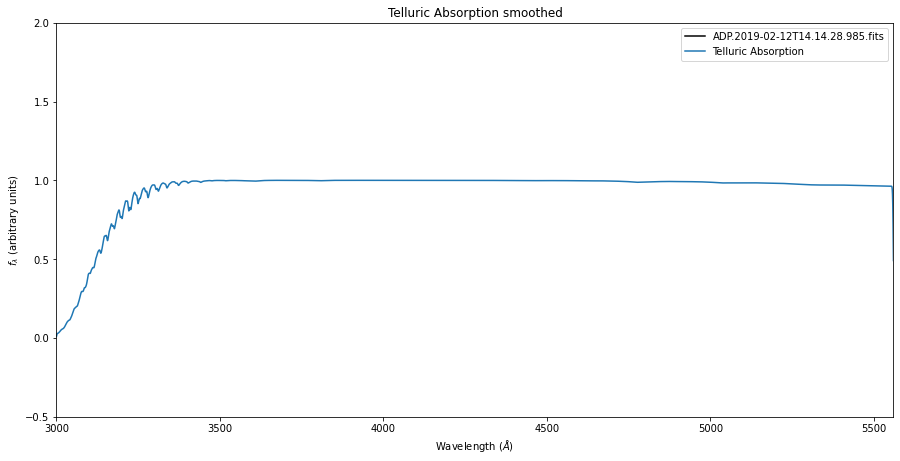

In [13]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=True, kernel_type='box', pix_width=40, color='k',norm_range=[10000,11000])
#plt.ylim([-2e-16,1e-16])
ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
plt.ylim([-0.5,2])
spt.show_plot()

ADP.2019-02-12T14.14.28.985.fits


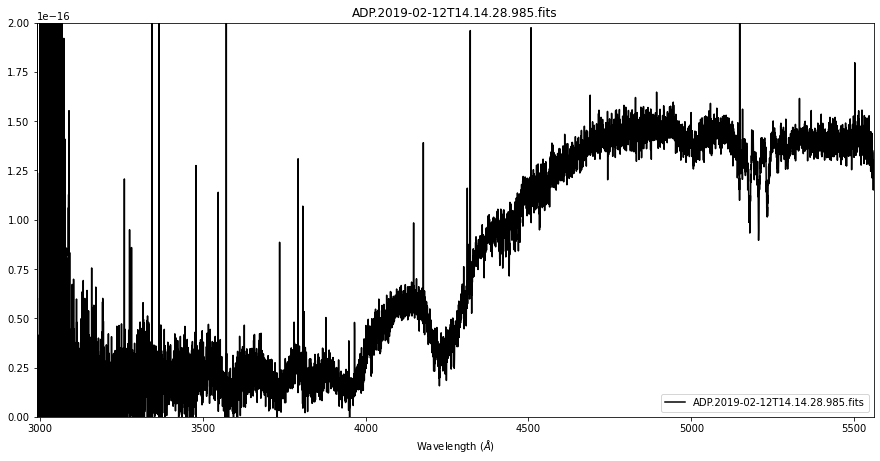

In [20]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=False, smooth=False, kernel_type='box', pix_width=40, color='k',norm_range=[10000,11000])
plt.ylim([0,0.2e-15])
#ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
#plt.ylim([-0.5,2])
spt.show_plot()



wavelength-based norm range selected [10000, 11000]



ADP.2019-02-12T14.14.28.985.fits smoothed normed[10000, 11000]
Telluric Absorption smoothed


/Users/BenKaiser/Desktop/radial_velocity_calculations/plot_spec.py:262: RuntimeWarning: Mean of empty slice
  out_flux= input_spec[1]/np.nanmean(input_spec[1][np.where((input_spec[0]>norm_range[0])&(input_spec[0]<norm_range[1]))])


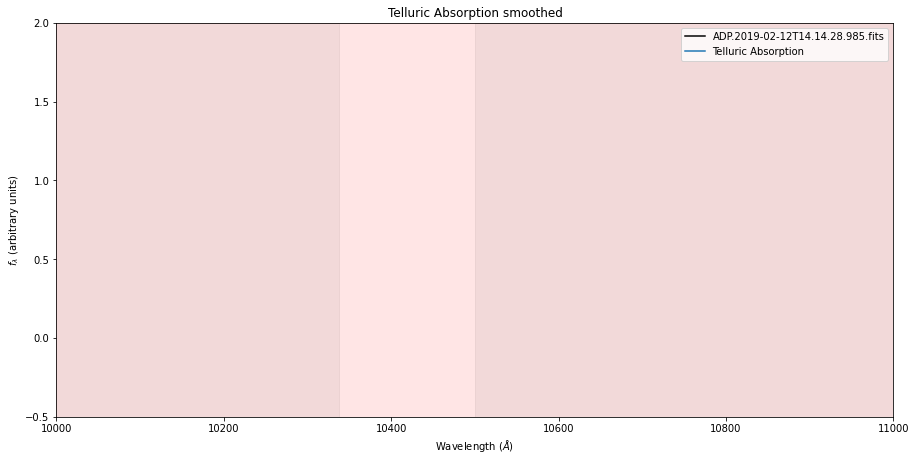

In [15]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=True, kernel_type='box', pix_width=4, color='k',norm_range=[10000,11000])
#plt.ylim([-2e-16,1e-16])
ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=5)
plt.ylim([-0.5,2])
plt.xlim([10000,11000])
spt.show_plot()



wavelength-based norm range selected [14500, 18000]



ADP.2019-02-12T14.14.28.985.fits smoothed normed[14500, 18000]
Telluric Absorption smoothed


/Users/BenKaiser/Desktop/radial_velocity_calculations/plot_spec.py:262: RuntimeWarning: Mean of empty slice
  out_flux= input_spec[1]/np.nanmean(input_spec[1][np.where((input_spec[0]>norm_range[0])&(input_spec[0]<norm_range[1]))])


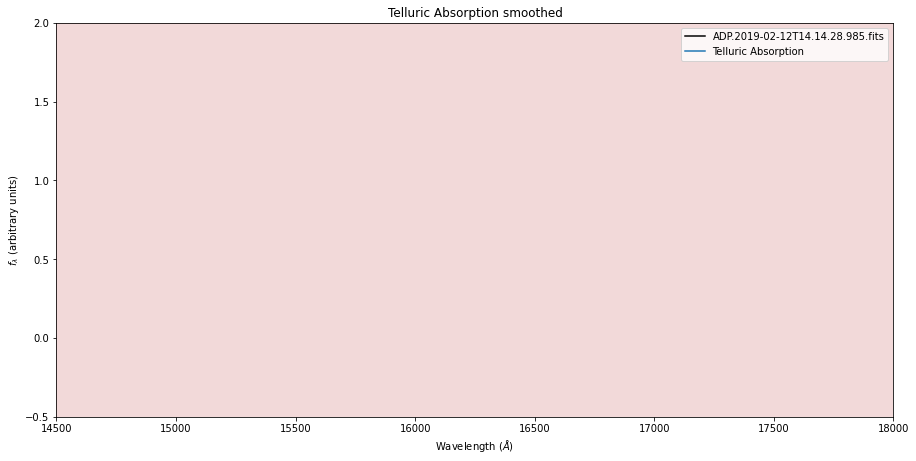

In [16]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=True, kernel_type='gaussian', pix_width=15, color='k',norm_range=[14500,18000],kernel_width=100)
#plt.ylim([-2e-16,1e-16])
ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=15)
plt.ylim([-0.5,2])
plt.xlim([14500,18000])
spt.show_plot()



wavelength-based norm range selected [6000, 6050]



ADP.2019-02-12T14.14.28.985.fits normed[6000, 6050]


/Users/BenKaiser/Desktop/radial_velocity_calculations/plot_spec.py:262: RuntimeWarning: Mean of empty slice
  out_flux= input_spec[1]/np.nanmean(input_spec[1][np.where((input_spec[0]>norm_range[0])&(input_spec[0]<norm_range[1]))])


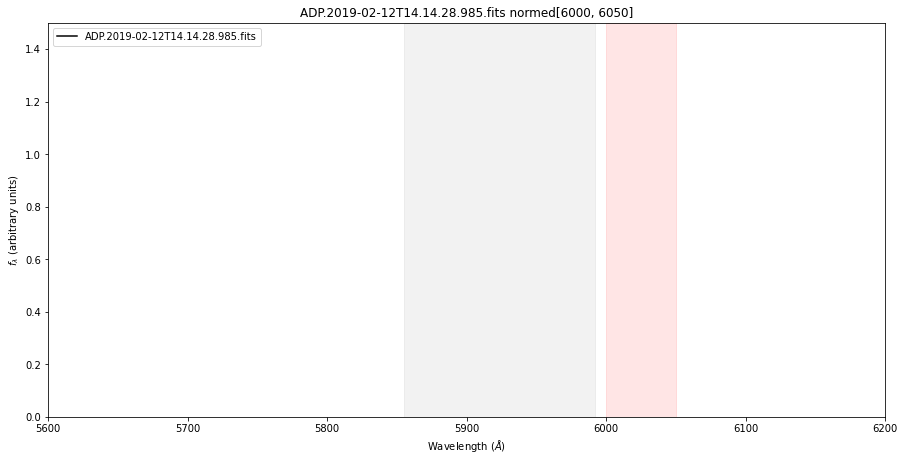

In [17]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=False, kernel_type='box', pix_width=40, color='k',norm_range=[6000,6050])
#plt.ylim([-2e-16,1e-16])
#ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
#plt.ylim([-0.5,2])
#plt.ylim(0,2e-16)
plt.ylim(0,1.5)
plt.xlim(5600,6200)
spt.show_plot()



wavelength-based norm range selected [6000, 6050]



ADP.2019-02-12T14.14.28.985.fits normed[6000, 6050]


/Users/BenKaiser/Desktop/radial_velocity_calculations/plot_spec.py:262: RuntimeWarning: Mean of empty slice
  out_flux= input_spec[1]/np.nanmean(input_spec[1][np.where((input_spec[0]>norm_range[0])&(input_spec[0]<norm_range[1]))])


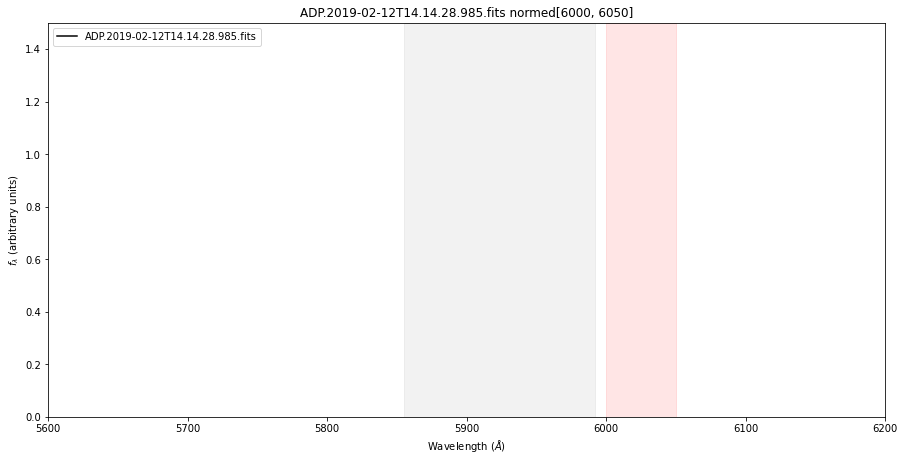

In [18]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=False, kernel_type='box', pix_width=40, color='k',norm_range=[6000,6050])
#plt.ylim([-2e-16,1e-16])
#ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
#plt.ylim([-0.5,2])
#plt.ylim(0,2e-16)
plt.ylim(0,1.5)
plt.xlim(5600,6200)
spt.show_plot()



wavelength-based norm range selected [6600, 6630]



ADP.2019-02-12T14.14.28.985.fits normed[6600, 6630]


/Users/BenKaiser/Desktop/radial_velocity_calculations/plot_spec.py:262: RuntimeWarning: Mean of empty slice
  out_flux= input_spec[1]/np.nanmean(input_spec[1][np.where((input_spec[0]>norm_range[0])&(input_spec[0]<norm_range[1]))])


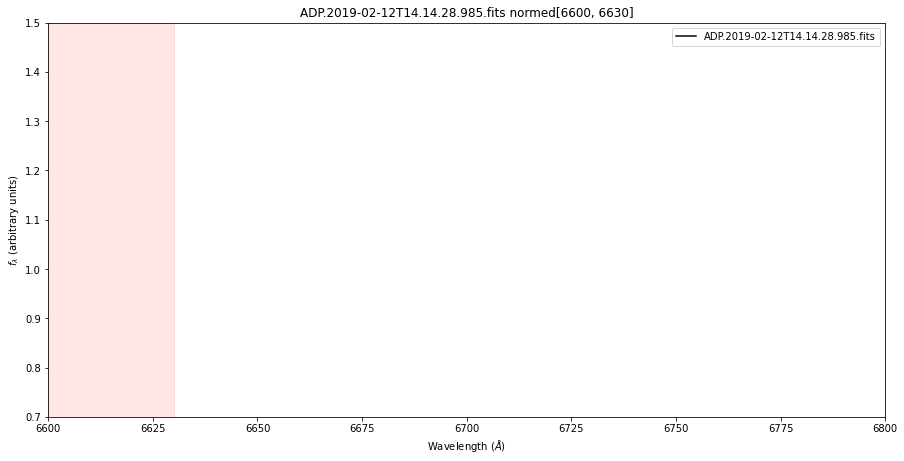

In [19]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=False, kernel_type='box', pix_width=40, color='k',norm_range=[6600,6630])
#plt.ylim([-2e-16,1e-16])
#ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
#plt.ylim([-0.5,2])
#plt.ylim(0,2e-16)
plt.ylim(0.7,1.5)
plt.xlim(6600,6800)
spt.show_plot()

ADP.2019-02-12T14.14.28.985.fits


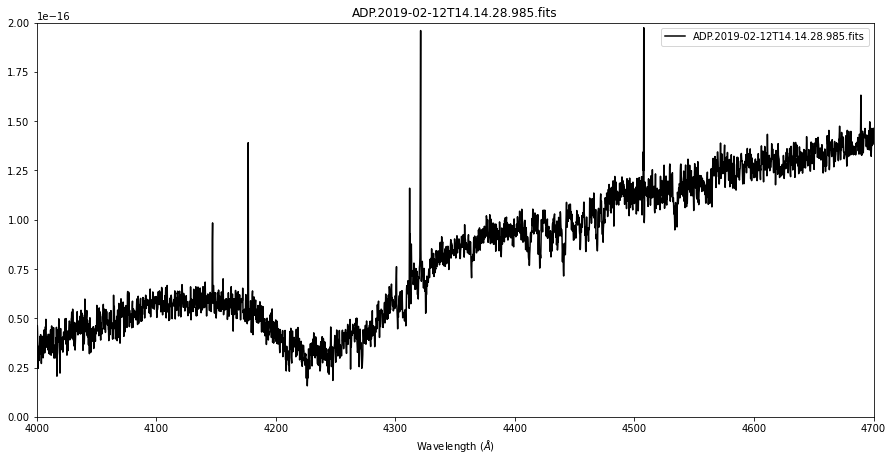

In [21]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=False, smooth=False, kernel_type='box', pix_width=40, color='k',norm_range=[10000,11000])
plt.ylim([0,0.2e-15])
#ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
#plt.ylim([-0.5,2])
plt.xlim(4000,4700)
spt.show_plot()

ADP.2019-02-12T14.14.28.985.fits


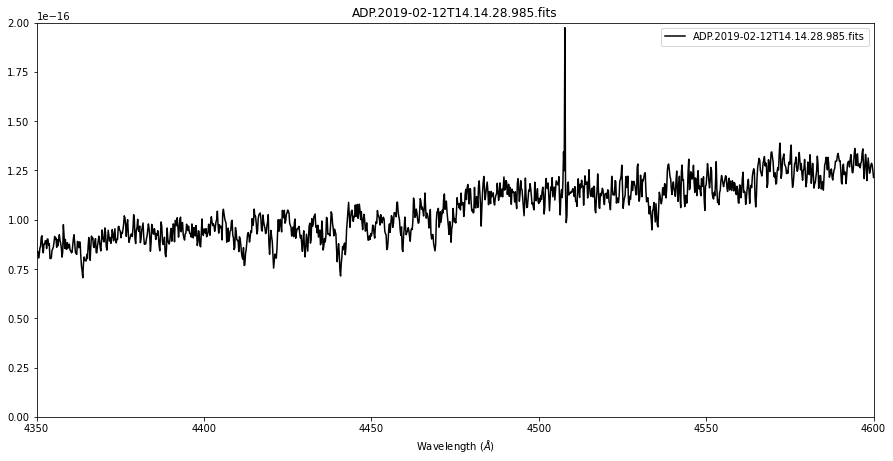

In [22]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=False, smooth=False, kernel_type='box', pix_width=40, color='k',norm_range=[10000,11000])
plt.ylim([0,0.2e-15])
#ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
#plt.ylim([-0.5,2])
plt.xlim(4350,4600)
spt.show_plot()

ADP.2019-02-12T14.14.28.985.fits smoothed


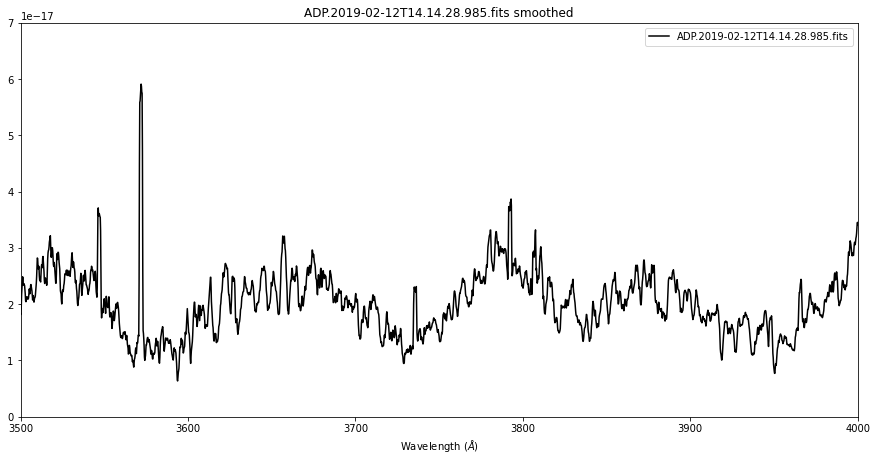

In [27]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=False, smooth=True, kernel_type='box', pix_width=10, color='k',norm_range=[10000,11000])
plt.ylim([0,0.7e-16])
#ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
#plt.ylim([-0.5,2])
plt.xlim(3500,4000)
spt.show_plot()